In [3]:
!pip install hmmlearn

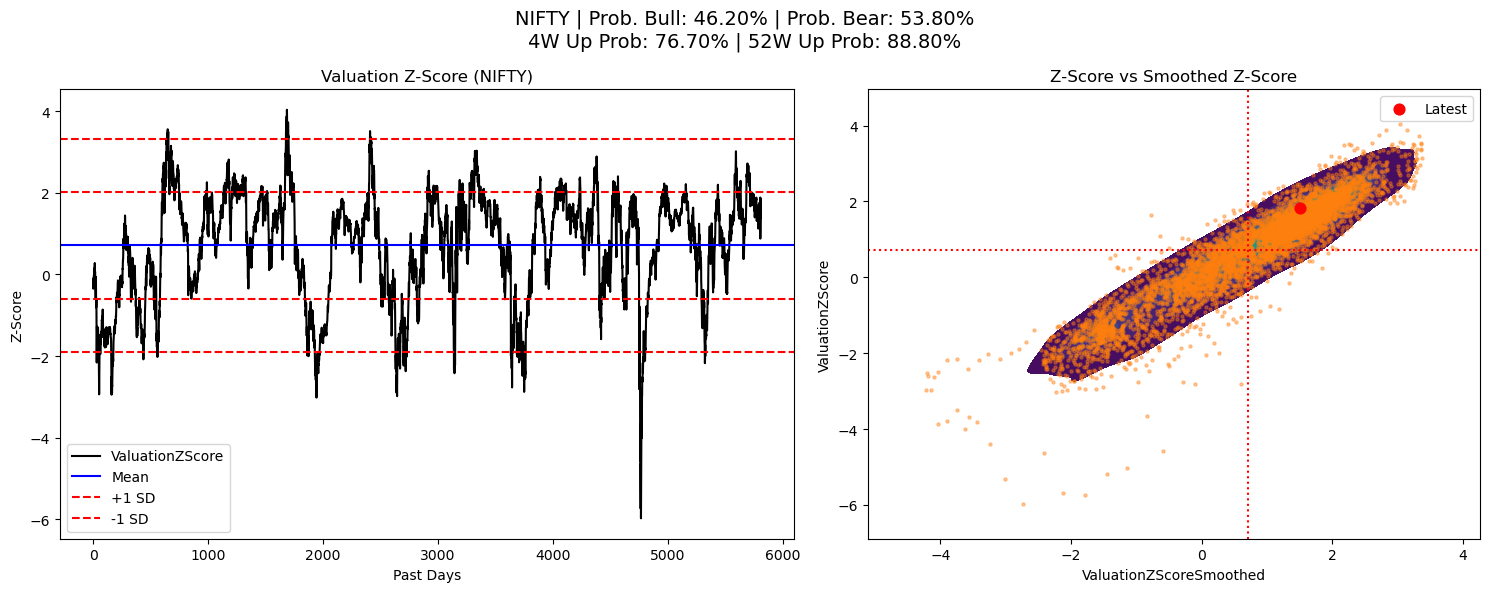

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pymysql
import warnings

warnings.filterwarnings("ignore")

# ---------------- CONFIG ----------------
host = 'localhost'
user = 'towdevuser'
password = 'Dev703'
database = 'timelineofwealth'
ticker = 'NIFTY'
from_date = '2000-01-03'

# ---------------- Load SQL Data ----------------
query = """
select ticker, date, value, pe, pb, div_yield 
from index_valuation 
where ticker = %s and date >= %s
order by date;
"""

connection = pymysql.connect(host=host, user=user, password=password, database=database)
df = pd.read_sql(query, connection, params=(ticker, from_date))
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# ---------------- Feature Engineering ----------------
# Z-Score Calculations (rolling 250-day window)
def zscore(series, window=250):
    return (series - series.rolling(window).mean()) / series.rolling(window).std()

df['ValuationZScore'] = zscore(df['value'])
df['PE_z'] = zscore(df['pe'])
df['PB_z'] = zscore(df['pb'])
df['DY_z'] = zscore(df['div_yield'])

# Smoothed ValuationZScore
df['ValuationZScoreSmoothed'] = df['ValuationZScore'].rolling(20).mean()

# Drop initial NaNs
df.dropna(inplace=True)

# ---------------- HMM Regime Classification ----------------
X_hmm = df[['ValuationZScore', 'ValuationZScoreSmoothed', 'PE_z', 'PB_z', 'DY_z']]
hmm_model = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000)
hmm_model.fit(X_hmm)
df['Regime'] = hmm_model.predict(X_hmm)

# Assign Bull/Bear labels
regime_means = pd.DataFrame(hmm_model.means_, columns=X_hmm.columns)
bull_regime = regime_means['ValuationZScore'].idxmin()
df['MarketRegime'] = df['Regime'].apply(lambda x: 'Bull' if x == bull_regime else 'Bear')

# Regime Probabilities
probs = hmm_model.predict_proba(X_hmm)
df['Prob_Bull'] = probs[:, bull_regime]
df['Prob_Bear'] = 1 - df['Prob_Bull']

# ---------------- Directional Target Creation ----------------
df['Future_4W'] = df['value'].shift(-20) / df['value'] - 1
df['Future_52W'] = df['value'].shift(-250) / df['value'] - 1
df['Target_4W'] = np.where(df['Future_4W'] > 0, 1, 0)
df['Target_52W'] = np.where(df['Future_52W'] > 0, 1, 0)

# Drop last 250 rows without future returns
df.dropna(inplace=True)

# ---------------- Supervised ML Prediction Models ----------------
features = ['ValuationZScore', 'ValuationZScoreSmoothed', 'PE_z', 'PB_z', 'DY_z']
X = df[features]
y_4w = df['Target_4W']
y_52w = df['Target_52W']

X_train4, X_test4, y_train4, y_test4 = train_test_split(X, y_4w, test_size=0.2, shuffle=False)
X_train52, X_test52, y_train52, y_test52 = train_test_split(X, y_52w, test_size=0.2, shuffle=False)

model_4w = RandomForestClassifier(n_estimators=100, max_depth=5)
model_52w = RandomForestClassifier(n_estimators=100, max_depth=5)

model_4w.fit(X_train4, y_train4)
model_52w.fit(X_train52, y_train52)

latest_features = df[features].iloc[-1].values.reshape(1, -1)
prob_up_4w = model_4w.predict_proba(latest_features)[0][1]
prob_up_52w = model_52w.predict_proba(latest_features)[0][1]

# ---------------- Chart Plot ----------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1.2, 1]})
fig.suptitle(f'NIFTY | Prob. Bull: {df["Prob_Bull"].iloc[-1]*100:.2f}% | Prob. Bear: {df["Prob_Bear"].iloc[-1]*100:.2f}%\n'
             f'4W Up Prob: {prob_up_4w*100:.2f}% | 52W Up Prob: {prob_up_52w*100:.2f}%', fontsize=14)

# Time Series Plot
axes[0].plot(df['ValuationZScore'].values, label='ValuationZScore', color='black')
axes[0].axhline(df['ValuationZScore'].mean(), color='blue', label='Mean')
axes[0].axhline(df['ValuationZScore'].mean() + df['ValuationZScore'].std(), linestyle='--', color='red', label='+1 SD')
axes[0].axhline(df['ValuationZScore'].mean() - df['ValuationZScore'].std(), linestyle='--', color='red', label='-1 SD')
axes[0].axhline(df['ValuationZScore'].mean() + 2*df['ValuationZScore'].std(), linestyle='--', color='red')
axes[0].axhline(df['ValuationZScore'].mean() - 2*df['ValuationZScore'].std(), linestyle='--', color='red')
axes[0].set_title("Valuation Z-Score (NIFTY)")
axes[0].set_xlabel("Past Days")
axes[0].set_ylabel("Z-Score")
axes[0].legend()

# Density Plot
sns.kdeplot(
    x=df['ValuationZScoreSmoothed'], 
    y=df['ValuationZScore'], 
    fill=True, cmap='viridis', ax=axes[1], thresh=0.05
)
axes[1].scatter(df['ValuationZScoreSmoothed'], df['ValuationZScore'], s=5, alpha=0.4)
axes[1].axhline(df['ValuationZScore'].mean(), linestyle='dotted', color='red')
axes[1].axvline(df['ValuationZScoreSmoothed'].mean(), linestyle='dotted', color='red')
axes[1].scatter(df['ValuationZScoreSmoothed'].iloc[-1], df['ValuationZScore'].iloc[-1], color='red', s=60, label='Latest')
axes[1].set_title("Z-Score vs Smoothed Z-Score")
axes[1].set_xlabel("ValuationZScoreSmoothed")
axes[1].set_ylabel("ValuationZScore")
axes[1].legend()

plt.tight_layout()
plt.show()